In [6]:
import numpy as np
from monai.data import DataLoader, CacheDataset
from dataset import get_dataset
from transforms import get_transforms
from monai.transforms import *
import matplotlib.pyplot as plt
import nibabel as nib

In [7]:
all_data = get_dataset("../../data")
subject = all_data[0]
subject

{'nacpet': '../../data/sub-000/features/nacpet.nii.gz',
 'topogram': '../../data/sub-000/features/topogram.nii.gz',
 'mri_combined_in_phase': '../../data/sub-000/features/mri_combined_in_phase.nii.gz',
 'mri_combined_out_phase': '../../data/sub-000/features/mri_combined_out_phase.nii.gz',
 'mri_face_mask': '../../data/sub-000/features/mri_face_mask.nii.gz',
 'mri_chunk_0_in_phase': '../../data/sub-000/features/mri_chunk_0_in_phase.nii.gz',
 'mri_chunk_0_out_phase': '../../data/sub-000/features/mri_chunk_0_out_phase.nii.gz',
 'mri_chunk_1_in_phase': '../../data/sub-000/features/mri_chunk_1_in_phase.nii.gz',
 'mri_chunk_1_out_phase': '../../data/sub-000/features/mri_chunk_1_out_phase.nii.gz',
 'mri_chunk_2_in_phase': '../../data/sub-000/features/mri_chunk_2_in_phase.nii.gz',
 'mri_chunk_2_out_phase': '../../data/sub-000/features/mri_chunk_2_out_phase.nii.gz',
 'mri_chunk_3_in_phase': '../../data/sub-000/features/mri_chunk_3_in_phase.nii.gz',
 'mri_chunk_3_out_phase': '../../data/sub-000/

In [8]:
patch_size = [195,170,131]
transforms = get_transforms(patch_size, 1)
patch = transforms(subject)
# patch= patches[0]

mid is 75


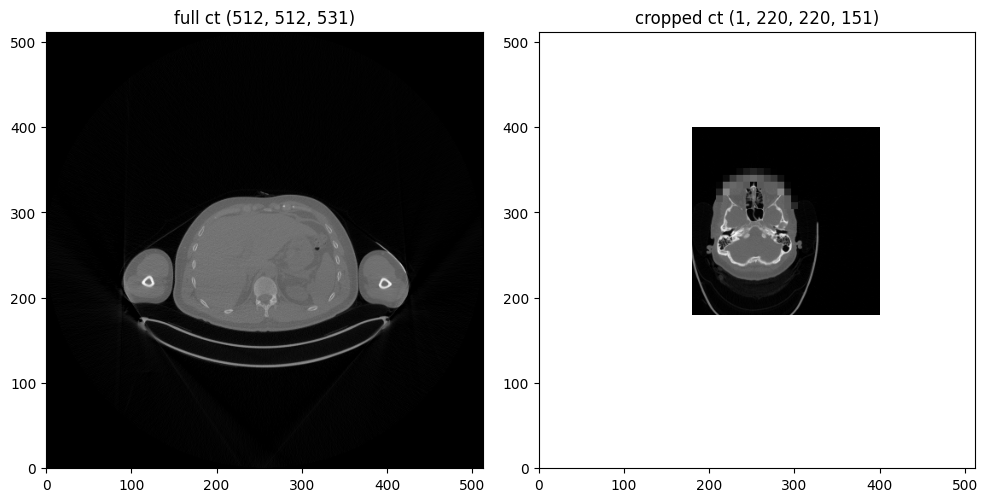

In [9]:
full_ct = nib.load(subject["ct"]).get_fdata()
full_mid = full_ct.shape[-1] // 2
mid = patch["ct"].shape[-1] // 2
print(f"mid is {mid}")

# must match SpatialCropd's roi_start in transforms.py, so the crop is drawn in its real position
roi_start = [180, 180]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(full_ct[..., full_mid].T, cmap="gray", origin="lower", extent=(0, full_ct.shape[0], 0, full_ct.shape[1]))
axes[0].set_title(f"full ct {full_ct.shape}")

crop_extent = (
    roi_start[0], roi_start[0] + patch["ct"].shape[1],
    roi_start[1], roi_start[1] + patch["ct"].shape[2],
)
axes[1].imshow(patch["ct"][0, ..., mid].T, cmap="gray", origin="lower", extent=crop_extent)
axes[1].set_title(f"cropped ct {tuple(patch['ct'].shape)}")

# same physical extent on both axes so the crop's true size and position are visible
for ax in axes:
    ax.set_xlim(0, full_ct.shape[0])
    ax.set_ylim(0, full_ct.shape[1])
plt.tight_layout()